In [ ]:
# %pip install spectral

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import spectral.io.envi as envi
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def load_cube(file_name):

    '''
    Takes in the filename and return its cube
    '''
    data = r'E:\main\projects\reflectance\data\reflectance1'
    data_dir = Path(data)

    header_file = str(data_dir / f'{file_name}.hdr')
    spectral_file = str(data_dir /f'{file_name}.bin')

    # open hyperspec cude
    image_cube = envi.open(header_file, spectral_file)

    print(f"Image dimensions (rows, cols, bands): {image_cube.shape}")
    print(f"Number of wavelengths (bands): {image_cube.nbands}")

    return image_cube


In [ ]:
img1 = load_cube('CC550_1_wt_100__Rep2_2024-08-30_15-21-55_Reflectance')

Image dimensions (rows, cols, bands): (760, 640, 201)
Number of wavelengths (bands): 201


In [ ]:

# open hyperspec cude
img2 = load_cube('CC350_1_wt_100__Rep1_2024-08-30_14-48-23_Reflectance')


Image dimensions (rows, cols, bands): (760, 640, 201)
Number of wavelengths (bands): 201


In [ ]:
wavelengths = img2.bands.centers
import numpy as np

print(np.min(wavelengths))
print(np.max(wavelengths))

900.0
1700.0


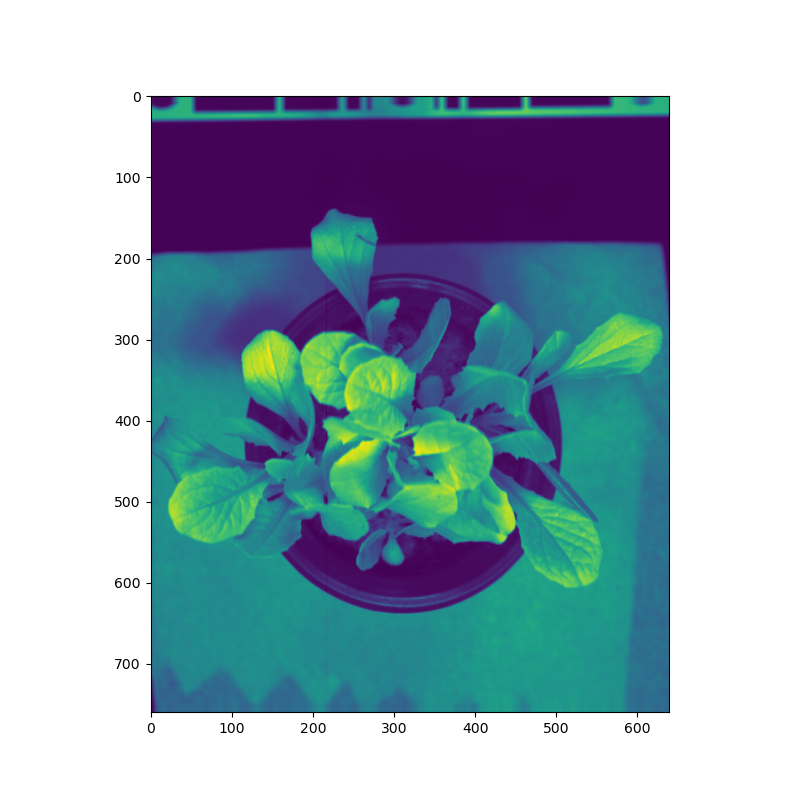

In [ ]:
band_index = 50

single_band = img2.read_band(band_index)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.imshow(single_band)#, cmap='gray' # FOR GRAY SCALE IMAGE

plt.show()

1. Select the points for the plant
2. Select the points for the background
3. Train SVM classifier
4. Predict in the hspec image


In [ ]:
%matplotlib widget

def get_plant_px(img_cube):

    hypercube = img_cube.load()

    display_band = hypercube[:, :, 50]

    plant_coords = [] # List to store plant coordinates

    fig, ax = plt.subplots()

    ax.imshow(display_band, cmap='viridis')
    ax.set_title("Click to select PLANT pixels")

    def onclick_plant(event):

        # Get integer coordinates of the click
        x, y = int(event.xdata), int(event.ydata)

        # Store the coordinates (row, col)
        plant_coords.append([y, x])

        # Draw a marker for visual feedback
        ax.plot(x, y, 'rx', markersize=8)
        fig.canvas.draw()

    # Connect the click event to our function
    cid = fig.canvas.mpl_connect('button_press_event', onclick_plant)
    plt.show() # Display the interactive plot

    return plant_coords

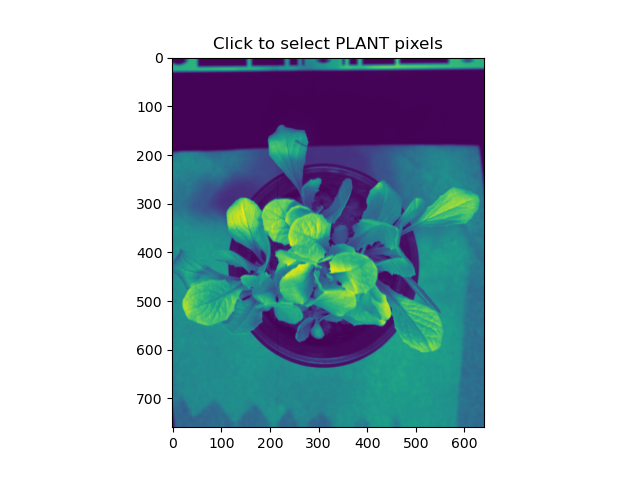

In [ ]:
plantsp = get_plant_px(img2)

In [ ]:
print(plantsp)

[[236, 588], [263, 597], [290, 543], [298, 484], [288, 381], [238, 422], [245, 397], [251, 296], [275, 290], [273, 327], [321, 272], [282, 212], [271, 181], [294, 150], [325, 171], [399, 179], [382, 185], [462, 64], [450, 124], [432, 146], [465, 194], [485, 192], [481, 222], [430, 231], [415, 210], [376, 261], [446, 270], [502, 288], [565, 274], [578, 292], [580, 319], [545, 335], [526, 307], [534, 272], [421, 407], [407, 389], [397, 362], [374, 381], [335, 340], [308, 436], [247, 549]]


In [ ]:
%matplotlib widget

def get_background_px(img_cube):

    hypercube = img_cube.load()
    display_band = hypercube[:, :, 50]

    background_coords = [] # List for background coordinates
    fig2, ax2 = plt.subplots()
    ax2.imshow(display_band, cmap='viridis')
    ax2.set_title("Click to select BACKGROUND pixels")

    def onclick_background(event):
        x, y = int(event.xdata), int(event.ydata)
        background_coords.append([y, x])
        ax2.plot(x, y, 'bo', markersize=5, markerfacecolor='none') # Blue circle marker
        fig2.canvas.draw()

    cid2 = fig2.canvas.mpl_connect('button_press_event', onclick_background)
    plt.show()

    return background_coords


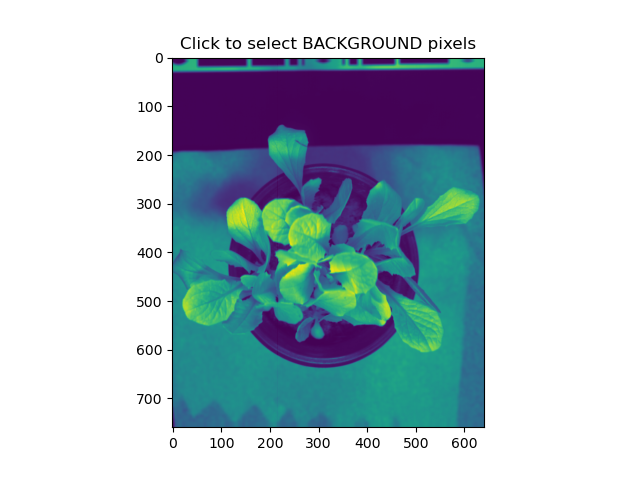

In [ ]:
backpx = get_background_px(img2)

In [ ]:

print(len(backpx))
print(len(plantsp))

77
41


In [ ]:
def train_svm(image_cube, plant_coords, background_coords):

    hypercube = image_cube.load()
    # --- Build the training data from your selected points ---
    X_train = []
    y_train = []
    bands = hypercube.shape[2]

    # Add plant pixels (Class 1)
    for r, c in plant_coords:
        X_train.append(hypercube[r, c, :].reshape(bands))
        y_train.append(1)

    # Add background pixels (Class 0)
    for r, c in background_coords:
        X_train.append(hypercube[r, c, :].reshape(bands))
        y_train.append(0)

    X_train = np.array(X_train)
    y_train = np.array(y_train)

    print(f"Training data created successfully!")
    print(f"Plant samples: {len(plant_coords)}")
    print(f"Background samples: {len(background_coords)}")
    print(f"Total training samples: {X_train.shape[0]}")

    # --- Step 2: Train the SVM Classifier ---
    # The 'C' and 'gamma' parameters can be tuned, but defaults are a good start.
    from sklearn.svm import SVC

    classifier = SVC(C=550, gamma='scale')
    classifier.fit(X_train, y_train)
    print("Classifier trained successfully!")

    # --- Step 3: Predict on the Entire Image ---
    # Reshape the hypercube to a long list of pixels (n_pixels, n_bands)
    rows, cols, bands = hypercube.shape
    img_reshaped = hypercube.reshape(rows * cols, bands)

    # Predict the class for every pixel
    predicted_labels = classifier.predict(img_reshaped)

    # Reshape the prediction back into a 2D image mask
    final_mask = predicted_labels.reshape(rows, cols)

    # --- Visualize the Result ---
    plt.figure(figsize=(8, 8))
    plt.imshow(final_mask, cmap='gray')
    plt.title('Segmentation Mask from SVM Classifier')
    plt.show()

    return final_mask, classifier


In [ ]:
def predict_svm(svm_classifier, image_cube):

    hypercube = image_cube.load()
    rows, cols, bands = image_cube.shape
    img_reshaped = hypercube.reshape(rows * cols, bands)

    # Predict the class for every pixel
    predicted_labels = svm_classifier.predict(img_reshaped)

    # Reshape the prediction back into a 2D image mask
    final_mask = predicted_labels.reshape(rows, cols)

    return final_mask

Training data created successfully!
Plant samples: 45
Background samples: 62
Total training samples: 107
Classifier trained successfully!


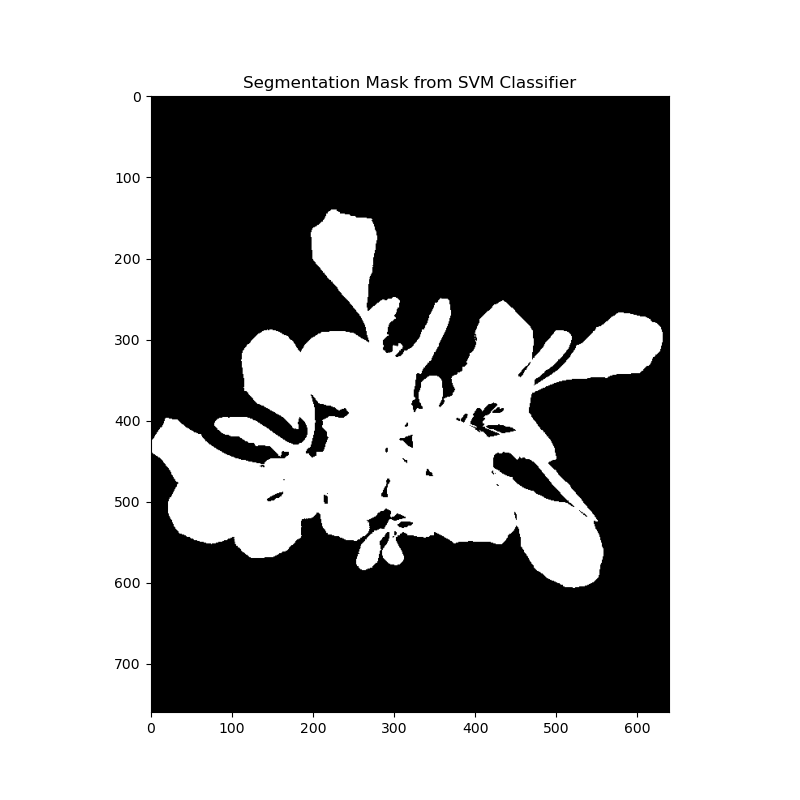

In [ ]:
svm_mask, svm_classifier = train_svm(img2, plantsp, backpx)

C:\Users\baolab\AppData\Local\Temp\ipykernel_14980\3163309258.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 2, figsize=(12, 6))


Text(0.5, 1.0, 'Final Mask New')

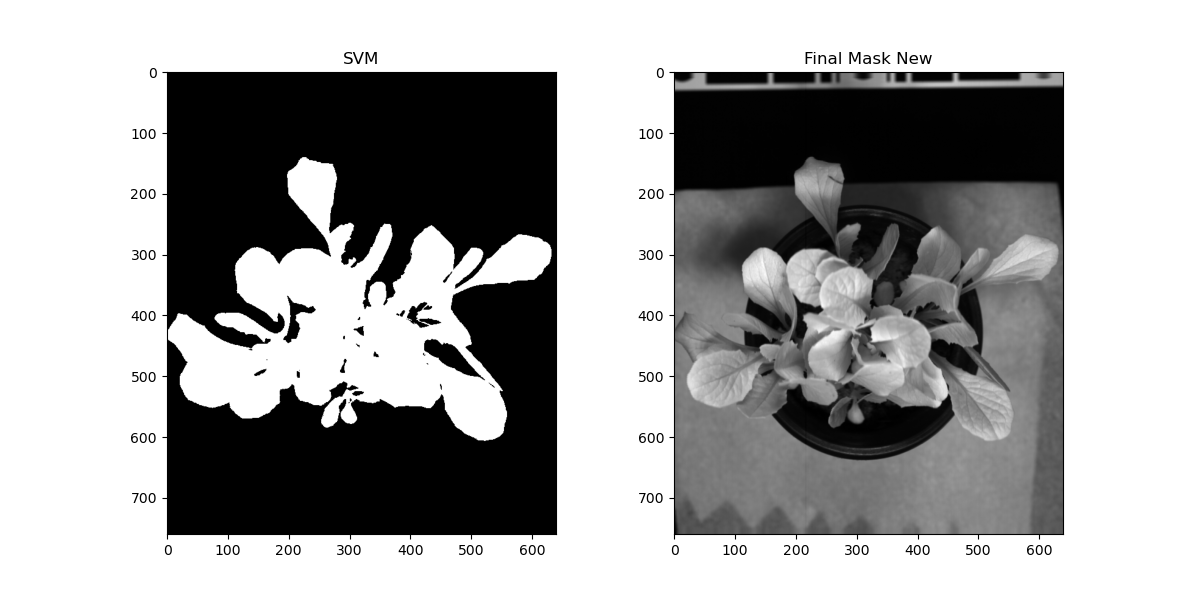

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(svm_mask, cmap='gray')
axes[0].set_title('SVM')

axes[1].imshow(single_band, cmap='gray')
axes[1].set_title('Final Mask New')


In [ ]:
svm_mask.shape

(760, 640)

In [ ]:
img2.shape

(760, 640, 201)

Shape of extracted plant pixels (num_pixels, num_bands): (122506, 201)
Shape of average reflectance spectrum: (201,)


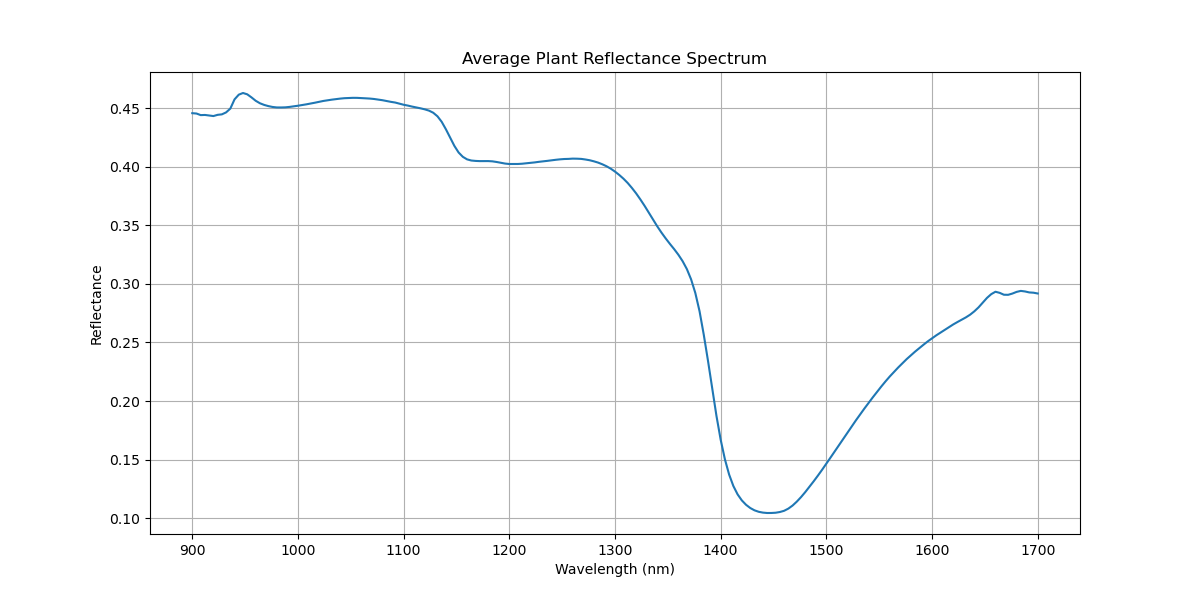

In [ ]:
hypercube_arr = np.array(img2.load())

svm_mask_bool = svm_mask.astype(bool)

plant_pixels = hypercube_arr[svm_mask_bool]
print(f"Shape of extracted plant pixels (num_pixels, num_bands): {plant_pixels.shape}")

# Calculate the average reflectance across all plant pixels for each band
average_reflectance = np.mean(plant_pixels, axis=0)
print(f"Shape of average reflectance spectrum: {average_reflectance.shape}")

# Now, plot the result for your manuscript!
plt.figure(figsize=(12, 6))
plt.plot(wavelengths, average_reflectance)
plt.title('Average Plant Reflectance Spectrum')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflectance')
plt.grid(True)
plt.show()

In [ ]:
average_reflectance

array([0.4452835 , 0.44497707, 0.44361654, 0.4437617 , 0.44325086,
       0.4428061 , 0.44383562, 0.4442237 , 0.44587174, 0.4489636 ,
       0.4566624 , 0.46049607, 0.46183556, 0.46067807, 0.45806155,
       0.45515576, 0.45303175, 0.45162538, 0.45060405, 0.44986042,
       0.4494586 , 0.44943696, 0.44954032, 0.4499034 , 0.45036978,
       0.45091093, 0.45146573, 0.45210686, 0.45276877, 0.45347598,
       0.45426866, 0.4549758 , 0.45553946, 0.45607564, 0.45654455,
       0.45698145, 0.45732135, 0.45750192, 0.45763025, 0.4576032 ,
       0.45745254, 0.4572196 , 0.45700255, 0.4566511 , 0.4561219 ,
       0.45560467, 0.45487607, 0.454204  , 0.45362872, 0.45269588,
       0.4517426 , 0.45103702, 0.45018452, 0.44946256, 0.44870415,
       0.44784206, 0.44673353, 0.44494876, 0.44192404, 0.4372403 ,
       0.43085992, 0.42371142, 0.41674843, 0.41111878, 0.40743533,
       0.40527177, 0.40428576, 0.4039435 , 0.40377593, 0.40376014,
       0.40379858, 0.4035794 , 0.40303156, 0.40237397, 0.40168

In [ ]:
# testing on unseen

unseen_mask = predict_svm(svm_classifier, img1)

Text(0.5, 1.0, 'Final Mask New')

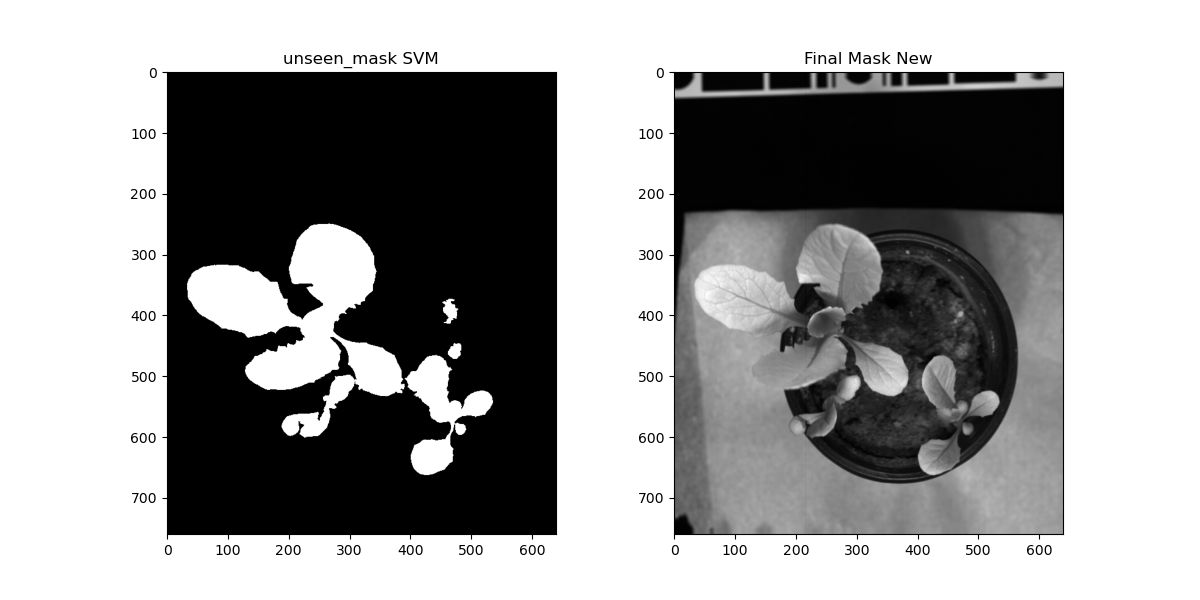

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(final_mask, cmap='gray')
axes[0].set_title('unseen_mask SVM')

axes[1].imshow(img1.read_band(50), cmap='gray')
axes[1].set_title('Final Mask New')


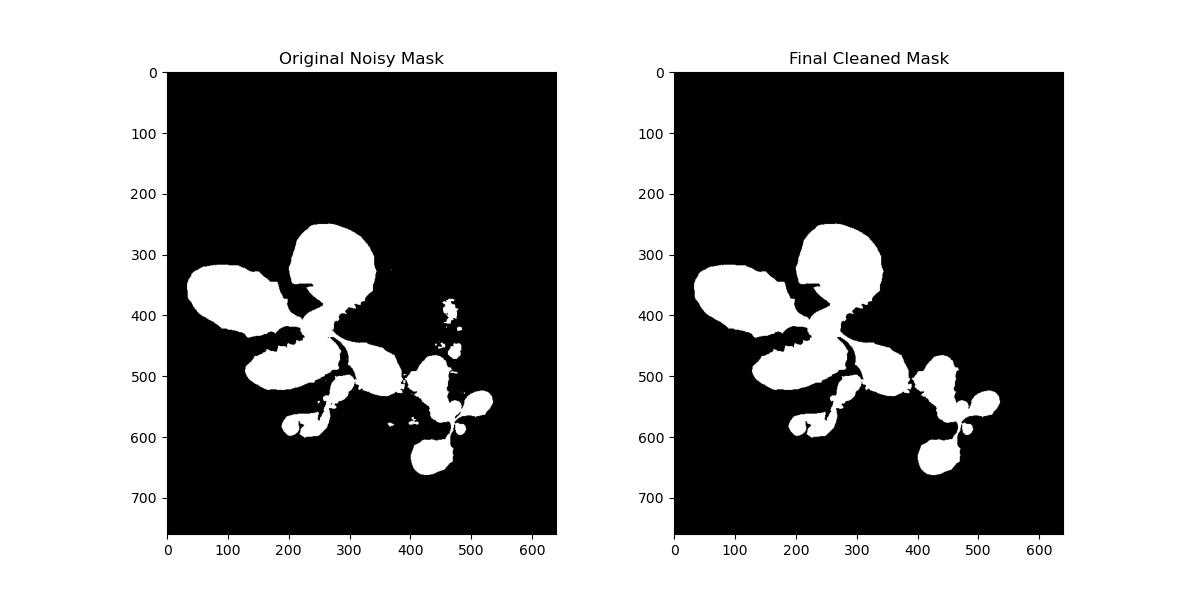

In [ ]:
from skimage.morphology import remove_small_objects, remove_small_holes
import matplotlib.pyplot as plt

# Assume 'noisy_mask' is your current mask with 1s for plant and 0s for background
# It should be a boolean array (True/False)
noisy_mask_bool = unseen_mask.astype(bool)

# --- Clean the mask ---

# 1. Remove small white speckles from the background
# Adjust 'min_size' based on your image. It's the minimum number of pixels
# an object must have to be kept.
cleaned_mask = remove_small_objects(noisy_mask_bool, min_size=650)

# 2. Fill small black holes inside the plant
# Adjust 'area_threshold' based on your image. It's the maximum size
# of a hole that will be filled.
final_mask = remove_small_holes(cleaned_mask, area_threshold=450)

# --- Visualize the results ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(noisy_mask_bool, cmap='gray')
axes[0].set_title('Original Noisy Mask')
axes[1].imshow(final_mask, cmap='gray')
axes[1].set_title('Final Cleaned Mask')
plt.show()

In [ ]:
# Assume 'hypercube' is your data and 'noisy_mask' is your current mask (as a boolean array)

noisy_mask = unknown_cube
hypercube = np.array(img.load())
# 1. Get the spectra of ALL pixels currently inside the noisy mask
pixels_to_check = hypercube[svm_mask]

# 2. Train your new "refinement" SVM model using the specific training data described above
# refinement_svm = SVC().fit(X_train_refined, y_train_refined)

# 3. Predict a new label (True Plant vs. Noise) for every pixel you extracted
new_labels = svm_classifier.predict(pixels_to_check)

# 4. Build the final, clean mask
# Start with an empty (all black) mask
clean_mask = np.zeros_like(noisy_mask, dtype=bool)

# Place the pixels that the model confirmed are "True Plant" (label 1) back into the mask
clean_mask[noisy_mask] = (new_labels == 1)

# Display your new, cleaner mask
plt.imshow(clean_mask, cmap='gray')
plt.show()

MemoryError: Unable to allocate 233. GiB for an array with shape (760, 640, 640, 201) and data type float32

In [ ]:
# SVM evaluation

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt

def train_and_evaluate_svm(image_cube, plant_coords, background_coords):

    hypercube = np.array(image_cube.load())
    X_all = []
    y_all = []
    bands = hypercube.shape[2]

    # Collect all labeled data
    for r, c in plant_coords:
        X_all.append(hypercube[r, c, :].reshape(bands))
        y_all.append(1)
    for r, c in background_coords:
        X_all.append(hypercube[r, c, :].reshape(bands))
        y_all.append(0)

    X_all = np.array(X_all)
    y_all = np.array(y_all)

    # --- Step 1: Split data for training and testing ---
    # test_size=0.2 means 20% of data is reserved for testing
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
    )

    print(f'Dataset size: {len(X_train), len(X_test), len(y_train), len(y_test)}')

    # --- Step 2: Train the model ONLY on the training set ---
    classifier = SVC(C=550, gamma='scale')
    classifier.fit(X_train, y_train)
    print("Classifier trained successfully!")

    # --- Step 3: Evaluate the model on the unseen test set ---
    print("\n--- Model Evaluation ---")
    y_pred = classifier.predict(X_test)

    # Print a detailed report
    # target_names=['background', 'plant'] makes the report readable
    report = classification_report(y_test, y_pred, target_names=['background', 'plant'])
    print(report)

    # --- Step 4: Create the final mask using the model trained on ALL data ---
    # For the best possible mask, it's good practice to retrain on all your labeled data
    final_classifier = SVC(C=550, gamma='scale').fit(X_all, y_all)

    rows, cols, bands = hypercube.shape
    img_reshaped = hypercube.reshape(rows * cols, bands)
    predicted_labels = final_classifier.predict(img_reshaped)
    final_mask = predicted_labels.reshape(rows, cols)

    plt.figure(figsize=(8, 8))
    plt.imshow(final_mask, cmap='gray')
    plt.title('Final Segmentation Mask')
    plt.show()

    return final_mask


Dataset size: (55, 14, 55, 14)
Classifier trained successfully!

--- Model Evaluation ---
              precision    recall  f1-score   support

  background       1.00      1.00      1.00         6
       plant       1.00      1.00      1.00         8

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00        14
weighted avg       1.00      1.00      1.00        14



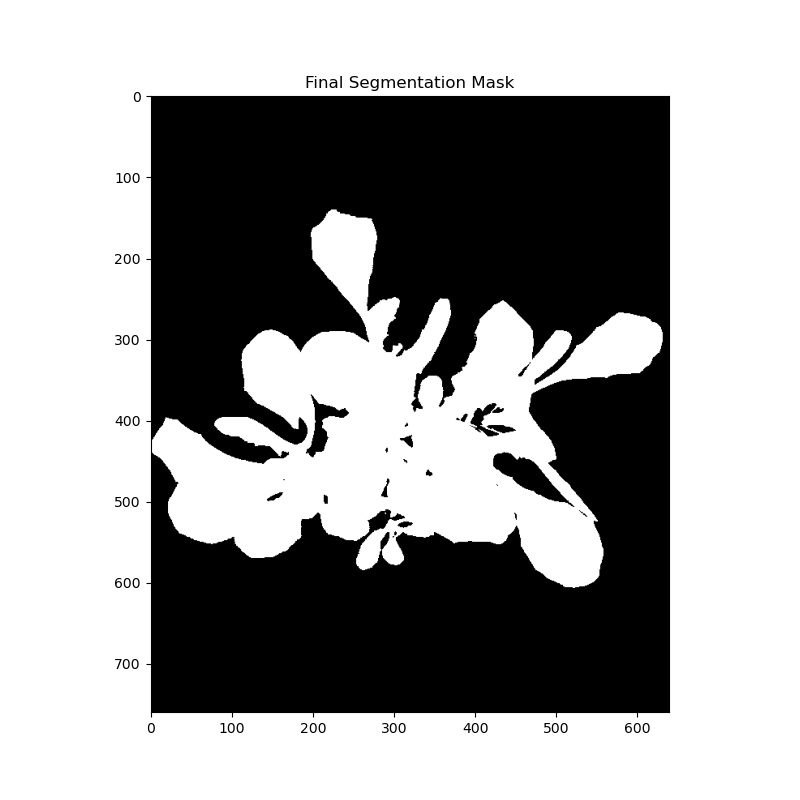

In [ ]:
# --- How to use it ---
svm_mask = train_and_evaluate_svm(img, plantsp, backpx)